# pdf2text-arabic: Visual Step-by-Step Test


### Step 1: Load PDF and View Original Page

This cell simply loads the PDF and displays the full page exactly as it appears in the file.


In [ ]:
import fitz
from IPython.display import display, Image

download_name = "مرسوم رقم 2.75.898-1751964855270"
pdf_path = f"download/{download_name}.pdf"
doc = fitz.open(pdf_path)
page = doc[3]  # Page 58

print(f"Loading original page 58 from {pdf_path}...")

pix_full = page.get_pixmap(dpi=100)
img_full_path = "full_page_view.png"
pix_full.save(img_full_path)

display(Image(filename=img_full_path))

FileNotFoundError: no such file: 'download/ocr_surgical_crop_0.pdf'

### Step 2: Apply Surgical Crops and Run OCR

This cell applies the 8% Top / 6% Bottom margins, shows you the result, and then extracts the text using DeepSeek-OCR.


VISUAL PREVIEW (Clipped Area for AI):


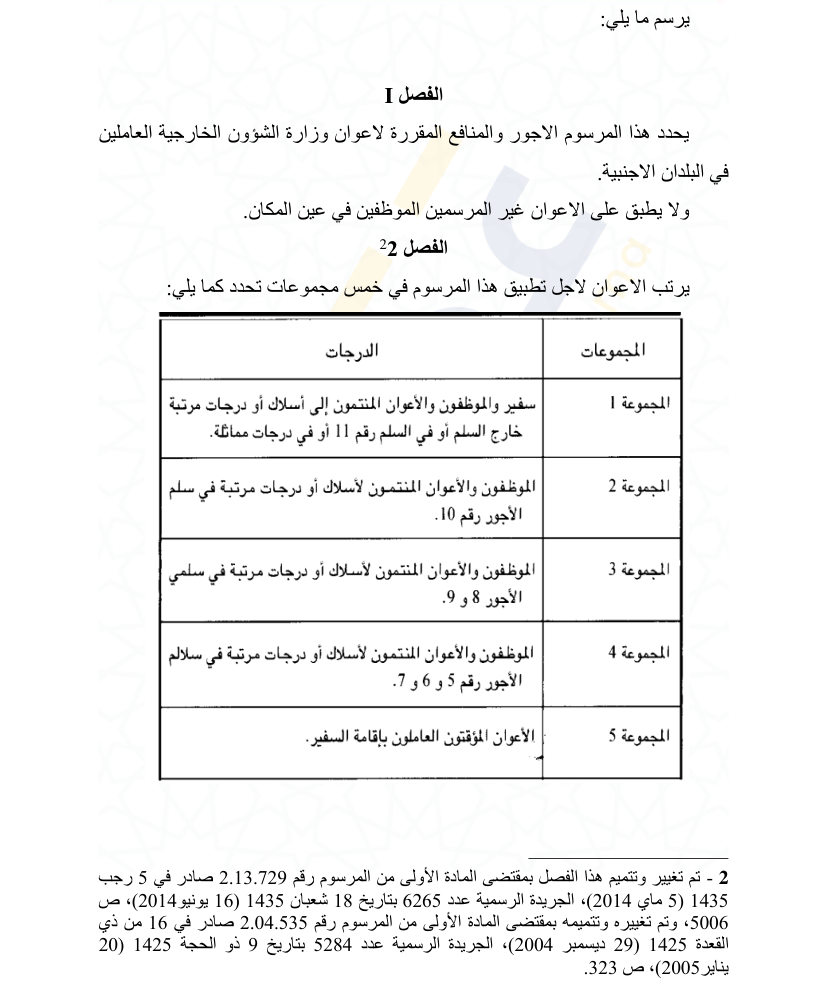


Extracting text via DeepSeek-OCR pipeline...

--- FINAL INTEGRATED OUTPUT ---
يرسم ما يلي:

الفصل I

يحدد هذا المرسوم الاجور والمنافع المقررة لاعوان وزارة الشؤون الخارجية العاملين

في البلدان الاجنبية.

ولا يطبق على الاعوان غير المرسمين الموظفين في عين المكان.

الفصل 2

يرتب الاعوان لاجل تطبيق هذا المرسوم في خمس مجموعات تحدد كما يلي:


In [4]:
import os
import sys
from pathlib import Path

# Ensure the local library is in the path
sys.path.append(str(Path(os.getcwd())))
from pdf2text_arabic._extract import extract_page

# 1. Show the Cropped Preview (8% Top, 8% Bottom)
h = page.rect.height
w = page.rect.width
crop_top_px = h * 0.08
crop_bottom_px = h * 0.075
clip = fitz.Rect(0, crop_top_px, w, h - crop_bottom_px)

pix_crop = page.get_pixmap(clip=clip, dpi=100)
img_crop_path = "crop_preview.png"
pix_crop.save(img_crop_path)

print("VISUAL PREVIEW (Clipped Area for AI):")
display(Image(filename=img_crop_path))

# 2. Run the actual library extraction
print("\nExtracting text via DeepSeek-OCR pipeline...")
text = extract_page(
    page, on_empty="ocr", crop_top=8, crop_bottom=8, crop_unit="pct", detect_footer=True
)

print("\n--- FINAL INTEGRATED OUTPUT ---")
print(text)

doc.close()